# Music Genre Classification - clean

In [1]:
import datetime
import os
from pathlib import Path
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import librosa
import soundfile as sf

### Set constants, check for required dirs

In [3]:
# Confirm that DATA_ROOT dir is readable
DATA_ROOT = Path('../Data_Music')
print('DATA_ROOT dir exists:', DATA_ROOT.exists())

# Confirm that GENRES_DIR is readable
GENRES_DIR = DATA_ROOT / 'original' / 'genres_original'
print('GENRES_DIR dir exists:', GENRES_DIR.exists())

# Print found genres
GENRES = sorted([d.name for d in GENRES_DIR.iterdir() if d.is_dir()])
print('Genres found:', GENRES)

DATA_ROOT dir exists: True
GENRES_DIR dir exists: True
Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


### Make dir for processed audio files

In [4]:
# Confirm that PROCESSED_DIR is readable
PROCESSED_DIR = DATA_ROOT / 'processed'
print('PROCESSED_DIR dir exists:', PROCESSED_DIR.exists())

for g in GENRES:
    subdir = PROCESSED_DIR / g
    if not os.path.exists(subdir):
        os.makedirs(subdir)

PROCESSED_DIR dir exists: True


### Define utils for finding audio files and checking metadata

In [5]:
def find_audio_files_within_dir(dir):
    # Traverse genre dirs, find names of each audio file
    found_audio_files = []
    for g in GENRES:
        for f in sorted((dir / g).glob('*.wav')):
            found_audio_files.append({'genre': g, 'filename': f.name, 'path': str(f)})

    # Convert found_audio_files to a pandas dataframe
    return pd.DataFrame(found_audio_files)

In [6]:
def get_metadata(audio_files_df):
    # Create empty list to store metadata of both readable and corrupted files
    metadata = []

    # Loop through every found audio file
    for audio_file in audio_files_df.itertuples(index=False):
        datum = {
            'genre': audio_file.genre,
            'filename': audio_file.filename,
            'path': audio_file.path,
        }
        try:
            # Read only the header of the file (fast, not full audio decode)
            info = sf.info(audio_file.path)
            datum.update({
                'duration': info.samplerate,
                'sample_rate': info.samplerate,
                'channels': info.channels,
                'corrupt': False,
            })
        except Exception as e:
            datum.update({
                'duration': np.nan,
                'sample_rate': np.nan,
                'channels': np.nan,
                'corrupt': True,
            })

        metadata.append(datum)

    # Convert metadata list to a dataframe
    return pd.DataFrame(metadata)

### Gather info about original audio files

We can see that there is only one corrupt audio file, which we know from `soundfile` throwing an exception when reading the header of the file. We see that all of our files have the same sample rate and roughly the same duration.

In [7]:
# Do the gathering
original_metadata_df = get_metadata(
    find_audio_files_within_dir(
        GENRES_DIR
    )
)

# Print helpful stats
readable_file_count = len(original_metadata_df[original_metadata_df['corrupt'] == False])
corrupt_file_count = len(original_metadata_df[original_metadata_df['corrupt'] == True])
print(f'Readable files: {readable_file_count}')
print(f'Corrupt files: {corrupt_file_count}')
print('---')
print('Sample rate values\n', original_metadata_df['sample_rate'].value_counts())
print('---')
print('Duration stats\n', original_metadata_df['duration'].value_counts())

Readable files: 999
Corrupt files: 1
---
Sample rate values
 sample_rate
22050.0    999
Name: count, dtype: int64
---
Duration stats
 duration
22050.0    999
Name: count, dtype: int64


### Split audio into 3-second samples

Since ~1,000 data points isn't sufficient to make credible model, we split the audio files into three second samples. The resulting files are stored in the `Data_Music/processed` subdir. This operation doesn't take too long, just 18 seconds on a cheap, old Dell desktop.

In [8]:
chunk_len_in_sec = 3
readable_audio_df = original_metadata_df[original_metadata_df['corrupt'] == False]

# Loop over metadata
for audio_file in readable_audio_df.itertuples():
    # Audio
    y, sr = librosa.load(Path(audio_file.path), mono='mono')

    # Goal: Carve the audio file into 3-sec chunks
    # Make dir for chunk files
    filename_without_ext = '.'.join(audio_file.filename.split('.')[0:-1])
    subdir = PROCESSED_DIR / audio_file.genre
    if not os.path.exists(subdir):
        os.makedirs(subdir)

    # First compute the start and end indices, then do the carving
    chunk_len_in_samples = chunk_len_in_sec * sr
    indicies = []
    for i in range(0, len(y), chunk_len_in_samples):
        end = i + chunk_len_in_samples
        if end <= len(y):
            indicies.append((i, end))

    for i, (start, end) in enumerate(indicies):
        path = subdir / f'{filename_without_ext}.{i:02}.wav'
        sf.write(path, y[start:end], sr)

/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Interpret results from audio file splitting

The number of readable files might seem *odd*.

Originally, we had 999 readable, 30-sec files and one corrupt file, however we now we only have 9,981 3-sec files, instead of 9,990. The reason for this difference is that some 30-sec files were slightly shorter than 30-sec. Because we specified the splits to be exactly three seconds long, some 30-sec files produced only 9 samples.

This approach seemed appropriate to us because we wanted to ensure that all data inputted into our ML model had the same duration. With this approach, we reduceed our total dataset duration by 27 seconds (ie. (9,990 - 9,981) * 3), which seems insignificant to us. The upshot is we don't have to pad/truncate our audio files, which is quite nice!

To make sure that our dataset isn't too unbalanced, as a result of this split operation, let's revisit the class balance visualization from the prior EDA notebook.

In [9]:
metadata_df = get_metadata(
    find_audio_files_within_dir(
        PROCESSED_DIR
    )
)

# Print helpful stats
readable_file_count = len(original_metadata_df[original_metadata_df['corrupt'] == False])
corrupt_file_count = len(original_metadata_df[original_metadata_df['corrupt'] == True])
print(f'Readable files: {readable_file_count}')
print(f'Corrupt files: {corrupt_file_count}')
print('---')
print('Sample rate values\n', original_metadata_df['sample_rate'].value_counts())
print('---')
print('Duration stats\n', original_metadata_df['duration'].value_counts())

Readable files: 999
Corrupt files: 1
---
Sample rate values
 sample_rate
22050.0    999
Name: count, dtype: int64
---
Duration stats
 duration
22050.0    999
Name: count, dtype: int64


Below we see that the classes aren't excessively unbalanced. Jazz is least represented genre, with only 990 samples, compared with several other genres that are fully represented, like blues and metal. Looks fine to continue on with the data processing!

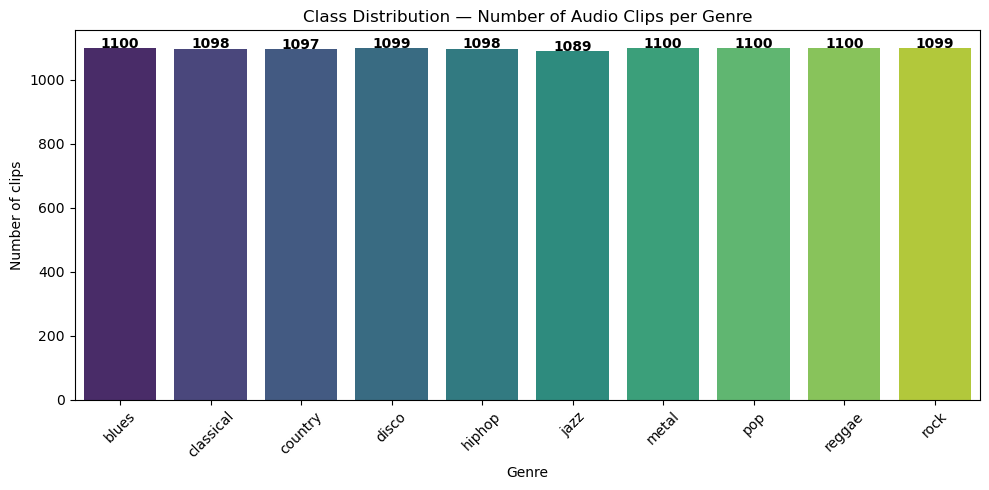

In [10]:
plt.figure(figsize=(10, 5))

counts = metadata_df['genre'].value_counts().sort_index()
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                 palette="viridis", legend=False)
ax.set_title('Class Distribution — Number of Audio Clips per Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of clips')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Extract features from audio data using librosa

The features of interest are:
* tempo
* mean chroma
* mfcc means (with n_mfcc=13)
* spectral centroid mean
* pectral rolloff mean
* zero crossing rate mean

This operation 4.5 min to run on that previously mentioned under-powered Dell desktop.

In [ ]:
# Setup time recording
print('Begin extracting features')
print('This will take a few minutes')
print('Start time:', datetime.datetime.now())
start = time.time()

mono = True
extracted_features_list = []

for path in find_audio_files_within_dir(PROCESSED_DIR)['path'].to_list():
    # Audio
    y, sr = librosa.load(Path(path), mono=mono)

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    
    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma)
    
    # MFCC (13 coefficients)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    #Normalize the MFCC array by computing the mean to 0 and computing the standard deviation to 1 
    mfcc_normalized = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / (np.std(mfcc, axis=1, keepdims=True) + 1e-8)
    
    # Spectral features
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    extracted_features_list.append({
        'tempo': tempo[0],
        'chroma_mean': chroma_mean,
        'mfcc array': mfcc_normalized,
        'spectral_centroid': spectral_centroid,
        'spectral_rolloff': spectral_rolloff,
        'zero_crossing_rate': zcr
    })

extracted_features_df = pd.DataFrame(extracted_features_list)
display(extracted_features_df)

# Print runtime
print('End time:', datetime.datetime.now())
elapsed_time = time.time() - start
print(f'Elapsed time {np.floor(elapsed_time / 60):.0f} min, {round(elapsed_time % 60)} sec')
print()
print('Extracted features below:')

Begin extracting features
This will take a few minutes
Start time: 2026-07-06 17:47:16.645192


,tempo,chroma_mean,mfcc array,spectral_centroid,spectral_rolloff,zero_crossing_rate
0,129.199219,0.335555,"[[-2.4711056, -1.8815254, -1.5295259, -1.14329...",1773.358004,3714.063439,0.081851
1,123.046875,0.343523,"[[-1.0119838, -0.60356814, -0.84619, -0.509135...",1817.244034,3870.510442,0.087173
2,123.046875,0.347746,"[[0.05602569, 0.20397198, -0.2829406, -0.69215...",1790.722358,4000.206581,0.071383
3,123.046875,0.363863,"[[0.22579215, 0.215818, -0.08384542, -0.110621...",1660.545231,3579.149639,0.069426
4,123.046875,0.335481,"[[-0.4040397, -0.14565118, -0.5485518, -0.5021...",1634.465076,3480.096905,0.070102
...,...,...,...,...,...,...
10975,83.354335,0.372556,"[[-0.4614992, 0.3188223, -0.040424515, -0.0890...",1852.706841,3754.728065,0.089111
10976,123.046875,0.347815,"[[0.14535846, 0.14971446, 0.11081608, 0.126508...",1348.383672,2445.509315,0.072194
10977,123.046875,0.386801,"[[0.69733614, 1.160321, 1.1156312, 1.1250879, ...",2086.306423,4317.655687,0.104072
10978,234.907670,0.368721,"[[-0.45215592, -0.15326118, -0.40766242, -0.41...",1635.796008,3464.775203,0.068502


End time: 2026-07-06 17:54:54.445954
Elapsed time 7 min, 38 sec

Extracted features below:


In [12]:
# Combine metadata and extracted features into one DataFrame
full_df = pd.concat([metadata_df, extracted_features_df], axis=1)
full_df

,genre,filename,path,duration,sample_rate,channels,corrupt,tempo,chroma_mean,mfcc array,spectral_centroid,spectral_rolloff,zero_crossing_rate
0,blues,blues.00000.00.wav,../Data_Music/processed/blues/blues.00000.00.wav,22050,22050,1,False,129.199219,0.335555,"[[-2.4711056, -1.8815254, -1.5295259, -1.14329...",1773.358004,3714.063439,0.081851
1,blues,blues.00000.01.wav,../Data_Music/processed/blues/blues.00000.01.wav,22050,22050,1,False,123.046875,0.343523,"[[-1.0119838, -0.60356814, -0.84619, -0.509135...",1817.244034,3870.510442,0.087173
2,blues,blues.00000.02.wav,../Data_Music/processed/blues/blues.00000.02.wav,22050,22050,1,False,123.046875,0.347746,"[[0.05602569, 0.20397198, -0.2829406, -0.69215...",1790.722358,4000.206581,0.071383
3,blues,blues.00000.03.wav,../Data_Music/processed/blues/blues.00000.03.wav,22050,22050,1,False,123.046875,0.363863,"[[0.22579215, 0.215818, -0.08384542, -0.110621...",1660.545231,3579.149639,0.069426
4,blues,blues.00000.04.wav,../Data_Music/processed/blues/blues.00000.04.wav,22050,22050,1,False,123.046875,0.335481,"[[-0.4040397, -0.14565118, -0.5485518, -0.5021...",1634.465076,3480.096905,0.070102
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10975,rock,rock.00099.06.wav,../Data_Music/processed/rock/rock.00099.06.wav,22050,22050,1,False,83.354335,0.372556,"[[-0.4614992, 0.3188223, -0.040424515, -0.0890...",1852.706841,3754.728065,0.089111
10976,rock,rock.00099.07.wav,../Data_Music/processed/rock/rock.00099.07.wav,22050,22050,1,False,123.046875,0.347815,"[[0.14535846, 0.14971446, 0.11081608, 0.126508...",1348.383672,2445.509315,0.072194
10977,rock,rock.00099.08.wav,../Data_Music/processed/rock/rock.00099.08.wav,22050,22050,1,False,123.046875,0.386801,"[[0.69733614, 1.160321, 1.1156312, 1.1250879, ...",2086.306423,4317.655687,0.104072
10978,rock,rock.00099.09.wav,../Data_Music/processed/rock/rock.00099.09.wav,22050,22050,1,False,234.907670,0.368721,"[[-0.45215592, -0.15326118, -0.40766242, -0.41...",1635.796008,3464.775203,0.068502


### Store the fully processed data

Here we save the full data DataFrame as a **csv file**, and put it in the processed subdir of the `Data_Music` folder. This csv file is 3 MiB in size and can be used by the SQL notebook. As a reminder, the SQL notebook will ensure that the data we have just written to disk is stored in a reliable and queryable way. Once it's in that state, it will be used by our model notebook.

In [13]:
full_df.to_csv(PROCESSED_DIR / 'data.csv', index=False)